In [1]:
import pandas as pd
import math
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import average_precision_score, roc_auc_score
import subprocess
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import average_precision_score
import subprocess
from sklearn.metrics.pairwise import cosine_distances
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from collections import defaultdict

In [2]:

def bpr_loss(s_pos, s_neg):
    return -torch.mean(torch.log(torch.sigmoid(s_pos - s_neg)))

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.2))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_eval(feat_cols, 
               df,
               df_test,
               train_idx,
               nn_lr = 1e-3,
               nn_epochs = 200,
               nn_hidden = (16,4,1),
               verbose = True):

    X_train = df.loc[train_idx, feat_cols].fillna(0).values
    y_train = df.loc[train_idx, "original"].values

    X_test = df_test[feat_cols].fillna(0).values
    y_test = df_test["label"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([0.5]).to(device))
    model = MLP(len(feat_cols), nn_hidden).to(device)
    opt = optim.Adam(model.parameters(), lr=nn_lr)

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)


    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)


    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]

    for ep in range(1, nn_epochs + 1):
        model.train()
        opt.zero_grad()

        # Balanceamento por Época (Under-sampling dos negativos)
        pos_idx = np.where(y_train == 1)[0]
        neg_idx = np.where(y_train == 0)[0]
        n_pos = len(pos_idx)
        
        # Sorteamos a mesma quantidade de negativos para cada época
        neg_sample = np.random.choice(neg_idx, n_pos, replace=False)
        combined_idx = np.concatenate([pos_idx, neg_sample])
        np.random.shuffle(combined_idx) # Mistura positivos e negativos

        # Forward pass
        batch_X = X_train_t[combined_idx]
        batch_y = y_train_t[combined_idx]
        
        outputs = model(batch_X) # Logits (saída sem ativação final)
        loss = criterion(outputs, batch_y)

        loss.backward()
        opt.step()

        # ... (bloco de validação verbose opcional) ...

    # Finalização e Métricas
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t)
        # Como usamos BCEWithLogitsLoss, a saída é o logit; aplicamos sigmoid aqui
        test_probs = torch.sigmoid(test_logits).cpu().numpy()

    # Cálculo das métricas de área (usando probabilidades contínuas)
    aupr = average_precision_score(y_test_t, test_probs)
    auroc = roc_auc_score(y_test_t, test_probs)

    # Matriz de Confusão (usando threshold 0.5)
    test_preds_binary = (test_probs >= 0.5).astype(int)
    print("\nMatriz de Confusão (BCE):")
    print(confusion_matrix(y_test_t, test_preds_binary))

    if verbose:
        print(f"Features: {feat_cols} -> AUPR: {aupr:.4f}, AUROC: {auroc:.4f}")

    return {"aupr": float(aupr), "auroc": float(auroc)}




def readFormatProbabilitys(adress:str):
    data = pd.read_csv(adress,header=None)
    
    values = []
    for i,j in data.groupby(1):
        values.append([j[0].values[0],j[1].values[0],j[2].values])

    df = pd.DataFrame(values)
    df = df.rename(columns={0:"leftNode",
                       1:"rightNode",
                       2:"probability"})
    return df

def readFormatExcludedlinks(adress:str):

   
    dfExcluded = pd.read_csv(adress,header=None)
    dfExcluded.rename(columns={0:"leftNode",
                               1:"rightNode"},inplace=True)
    dfExcluded["leftNode"] = dfExcluded["leftNode"].astype("int64")
    dfExcluded["rightNode"] = dfExcluded["rightNode"].astype("int64")

    
    return dfExcluded


def getL3(args, train_graph):
    train_graph_df = pd.read_csv(train_graph, header=None)
    train_graph_df["weight"] = 1
    train_graph_df.to_csv(f"{args.exec_path}/data/kpisti-L3-a163e9f/graph.txt", header=None, sep=" ", index=False)
    
    subprocess.run(f"{args.exec_path}/data/kpisti-L3-a163e9f/teste.out {args.exec_path}/data/kpisti-L3-a163e9f/graph.txt", shell=True)
    subprocess.run(f"mv {args.exec_path}/data/kpisti-L3-a163e9f/L3_predictions_graph.txt.dat {args.exec_path}/data/kpisti-L3-a163e9f/L3_predictions_graph.txt", shell=True)
    
    result = pd.read_csv(f"{args.exec_path}/data/kpisti-L3-a163e9f/L3_predictions_graph.txt", sep="\t", header=None)
    print(result)
    result.columns = ["rightNode", "leftNode", "pred"]
    print("Pares antes do filtro:", len(result))
    # normalizar tipos
    result["leftNode"] = result["leftNode"].astype(str).str.strip()
    result["rightNode"] = result["rightNode"].astype(str).str.strip()
    print(result.head())
    print("Antes do filtro:", len(result))
    # excluir arestas que já existem no treino
    train_edges = set(
        zip(
            train_graph_df[0].astype(str).str.strip(),
            train_graph_df[1].astype(str).str.strip()
        )
    )
    mask = [
        (l, r) not in train_edges
        for l, r in zip(result["leftNode"], result["rightNode"])
    ]
    result = result[mask].reset_index(drop=True)
    return result

def getCommonNeighbors(train_graph_path):
    """
    Compute a bipartite-aware "common neighbors" score for left->right pairs.
    We use the biadjacency matrix B (L x R) and compute M = B * B.T * B (L x R).
    M[i,j] counts length-3 paths left_i -> right_k -> left_l -> right_j, a useful
    bipartite analogue for common-neighbors-based link scoring.
    Returns a DataFrame with columns ["rightNode","leftNode","pred"] sorted by pred desc.
    """
    import scipy.sparse as sp
    import numpy as np

    g = pd.read_csv(train_graph_path, header=None)
    if g.shape[1] < 2:
        raise ValueError("train_graph must have at least two columns (left,right)")
    g = g.rename(columns={0: "leftNode", 1: "rightNode"})
    g["leftNode"] = g["leftNode"].astype(str).str.strip()
    g["rightNode"] = g["rightNode"].astype(str).str.strip()

    left_nodes = pd.Index(g["leftNode"].unique())
    right_nodes = pd.Index(g["rightNode"].unique())
    nL = len(left_nodes)
    nR = len(right_nodes)
    idxL = {n: i for i, n in enumerate(left_nodes)}
    idxR = {n: i for i, n in enumerate(right_nodes)}

    rows = g["leftNode"].map(idxL).values
    cols = g["rightNode"].map(idxR).values
    data = np.ones(len(rows), dtype=float)

    # biadjacency matrix B (L x R)
    B = sp.csr_matrix((data, (rows, cols)), shape=(nL, nR), dtype=float)

    # compute M = B * B.T * B  -> shape L x R
    # this counts length-3 paths between left i and right j
    # use sparse multiplications
    M = (B.dot(B.T)).dot(B)  # (LxL) * (LxR) -> LxR

    M_coo = M.tocoo()
    if M_coo.nnz == 0:
        return pd.DataFrame(columns=["rightNode", "leftNode", "pred"])

    lefts = left_nodes.values[M_coo.row]
    rights = right_nodes.values[M_coo.col]
    preds = M_coo.data

    df_out = pd.DataFrame({"leftNode": lefts, "rightNode": rights, "pred": preds})
    # remove trivial self-like matches if any and sort
    df_out = df_out[df_out["leftNode"] != df_out["rightNode"]]
    df_out = df_out.sort_values("pred", ascending=False).reset_index(drop=True)
    # match L3/Katz ordering
    df_out = df_out[["rightNode", "leftNode", "pred"]]
    return df_out
def getGD(train_graph_path,
           max_dist: int = 5,
           alpha: float = 1.0,
           exclude_existing: bool = True,
           normalize: bool = False):
    """
    Bipartite-aware GD:
      - builds undirected adjacency from training edges (string nodes)
      - BFS from each left node up to max_dist
      - records distances to right-side nodes only and only odd-length distances
      - score = exp(-alpha * (dist-1))  (dist=1 -> score=1.0)
      - can exclude edges that already exist in training (exclude_existing=True)
      - optional min-max normalization across scores (normalize=True)

    Returns DataFrame with columns ["rightNode","leftNode","pred"] sorted by pred desc.
    """
    from collections import deque, defaultdict
    import math

    g = pd.read_csv(train_graph_path, header=None)
    if g.shape[1] < 2:
        raise ValueError("train_graph must have at least two columns (left,right)")
    g = g.rename(columns={0: "leftNode", 1: "rightNode"})
    # use strings to avoid accidental numeric overlap
    g["leftNode"] = g["leftNode"].astype(str).str.strip()
    g["rightNode"] = g["rightNode"].astype(str).str.strip()

    left_nodes = list(g["leftNode"].unique())
    right_nodes = list(g["rightNode"].unique())
    left_set = set(left_nodes)
    right_set = set(right_nodes)

    # adjacency (undirected)
    adj = defaultdict(set)
    existing_edges = set()
    for ln, rn in zip(g["leftNode"].values, g["rightNode"].values):
        adj[ln].add(rn)
        adj[rn].add(ln)
        existing_edges.add((ln, rn))

    rows = []
    for ln in left_nodes:
        # BFS from ln
        q = deque()
        q.append((ln, 0))
        dist = {ln: 0}
        while q:
            node, d = q.popleft()
            if d >= max_dist:
                continue
            for nb in adj.get(node, ()):
                if nb not in dist:
                    nd = d + 1
                    dist[nb] = nd
                    q.append((nb, nd))
        # collect right-node distances (only odd distances correspond to left->right paths)
        for rn, d in dist.items():
            if rn in right_set and rn != ln and d >= 1 and (d % 2 == 1):
                if exclude_existing and (ln, rn) in existing_edges:
                    continue
                score = 1/d
                rows.append({"leftNode": ln, "rightNode": rn, "pred": score})

    if not rows:
        return pd.DataFrame(columns=["rightNode", "leftNode", "pred"])

    df_out = pd.DataFrame(rows)
    # optional normalization to [0,1]
    if normalize:
        minv = df_out["pred"].min()
        maxv = df_out["pred"].max()
        if maxv > minv:
            df_out["pred"] = (df_out["pred"] - minv) / (maxv - minv)

    df_out = df_out.sort_values("pred", ascending=False).reset_index(drop=True)
    df_out = df_out[["rightNode", "leftNode", "pred"]]
    return df_out

def getKatz(train_graph_path,
            max_path_len: int = 5,
            beta: float = 0.05,
            symmetrize: bool = True):
    """
    Compute Katz index scores and keep only predictions
    from original leftNode -> original rightNode pairs.

    """
    import scipy.sparse as sp
    from scipy.sparse.linalg import eigs
    import numpy as np

    # load graph
    g = pd.read_csv(train_graph_path, header=None)
    if g.shape[1] < 2:
        raise ValueError("train_graph must have at least two columns (left,right)")
    g = g.rename(columns={0: "leftNode", 1: "rightNode"})
    g["leftNode"] = g["leftNode"].astype(str).str.strip()
    g["rightNode"] = g["rightNode"].astype(str).str.strip()

    # remember original partitions
    left_set = set(g["leftNode"].unique())
    right_set = set(g["rightNode"].unique())

    # build node index (all nodes)
    nodes = pd.Index(pd.concat([g["leftNode"], g["rightNode"]]).unique())
    nodes_arr = nodes.values
    n = len(nodes_arr)
    idx = {node: i for i, node in enumerate(nodes_arr)}

    rows = g["leftNode"].map(idx).values
    cols = g["rightNode"].map(idx).values
    data = np.ones(len(rows), dtype=float)

    A = sp.csr_matrix((data, (rows, cols)), shape=(n, n), dtype=float)
    if symmetrize:
        A = A + A.T
        A.data = np.clip(A.data, 0, 1)



    # truncated Katz series
    S = sp.csr_matrix((n, n), dtype=float)
    A_pow = A.copy()
    for l in range(1, max_path_len + 1):
        S = S + (beta ** l) * A_pow
        A_pow = A_pow.dot(A)

    S_coo = S.tocoo()
    if S_coo.nnz == 0:
        return pd.DataFrame(columns=["rightNode", "leftNode", "pred"])

    lefts = nodes_arr[S_coo.row]
    rights = nodes_arr[S_coo.col]
    preds = S_coo.data

    df_out = pd.DataFrame({"leftNode": lefts, "rightNode": rights, "pred": preds})

    # remove self-loops
    df_out = df_out[df_out["leftNode"] != df_out["rightNode"]]

    # if bipartite, keep only original left->right pairs (avoid same-side predictions)
    df_out = df_out[df_out["leftNode"].isin(left_set) & df_out["rightNode"].isin(right_set)]

    # sort by score desc
    df_out = df_out.sort_values("pred", ascending=False).reset_index(drop=True)

    # keep same L3 ordering convention if needed (rightNode,leftNode,pred)
    df_out = df_out[["rightNode", "leftNode", "pred"]]

    return df_out


def evaluateAllModels(args,
                      ourmethod_dir,
                      train_graph_path,
                      test_graph_path,
                      katz_max_path_len: int = 5,
                      katz_beta: float = 0.05,
                      holdout_blue_frac: float = 0.5,
                      random_state: int = 0,
                      verbose: bool = True):

    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.model_selection import train_test_split

    rng = np.random.RandomState(random_state)

    results = {
        "l3": {}, "katz": {}, "common_neighbors": {}, "GD": {},
        "nn_controlled": {}, "nn_realistic": {}
    }

    # --- test ground-truth ---
    df_test = readFormatExcludedlinks(test_graph_path)
    df_test["leftNode"] = df_test["leftNode"].astype(str).str.strip()
    df_test["rightNode"] = df_test["rightNode"].astype(str).str.strip()
    df_test["_exists"] = 1

    # ------------------------------------------------------------------ #
    def _eval_model(df_pred, name, train_graph_path,verbose = True):
        if df_pred is None or df_pred.empty:
            if verbose: print(f"{name} returned no predictions.")
            return {"1:1": {"aupr": None, "auroc": None},
                    "1:10": {"aupr": None, "auroc": None}}

        for c in ["leftNode", "rightNode"]:
            df_pred[c] = df_pred[c].astype(str).str.strip()

        # gerar todos os pares possíveis
        train = pd.read_csv(train_graph_path, header=None)\
                .rename(columns={0:"leftNode", 1:"rightNode"})\
                .astype(str)
        left_nodes  = train["leftNode"].unique()
        right_nodes = train["rightNode"].unique()

        all_pairs = pd.MultiIndex.from_product(
            [left_nodes, right_nodes], names=["leftNode","rightNode"]
        ).to_frame(index=False).reset_index(drop=True)

        # pares sem predição recebem score 0
        all_pairs = all_pairs.merge(df_pred, on=["leftNode","rightNode"], how="left")
        all_pairs["pred"] = all_pairs["pred"].fillna(0)

        # labels
        all_pairs = all_pairs.merge(df_test[["leftNode","rightNode","_exists"]],
                                    on=["leftNode","rightNode"], how="left")

        y_true  = all_pairs["_exists"].fillna(0).astype(int).values
        y_score = all_pairs["pred"].values

        def _metrics(yt, ys, label):
            if yt.sum() == 0:
                if verbose: 
                    print(f"{name} [{label}] -> sem positivos")
                return {"aupr": 0.0, "auroc": None}
            aupr = float(average_precision_score(yt, ys))
            try:
                auroc = float(roc_auc_score(yt, ys)) if len(np.unique(yt)) > 1 else None
            except Exception:
                auroc = None
            if verbose: 
                print(f"{name} [{label}] -> AUPR: {aupr:.4f}, AUROC: {auroc}")
            return {"aupr": aupr, "auroc": auroc}

        pos_idx = np.where(y_true == 1)[0]
        neg_idx = np.where(y_true == 0)[0]
        n_pos   = len(pos_idx)

        neg_1_1  = rng.choice(neg_idx, size=min(n_pos, len(neg_idx)),      replace=False)
        neg_1_10 = rng.choice(neg_idx, size=min(10 * n_pos, len(neg_idx)), replace=False)

        idx_1_1  = np.concatenate([pos_idx, neg_1_1])
        idx_1_10 = np.concatenate([pos_idx, neg_1_10])

        return {
            "full": _metrics(y_true, y_score, "full"),
            "1:1":  _metrics(y_true[idx_1_1],  y_score[idx_1_1],  "1:1"),
            "1:10": _metrics(y_true[idx_1_10], y_score[idx_1_10], "1:10"),
        }
    # ------------------------------------------------------------------ #

    # --- L3 ---



    # try:
    #     results["l3"] = _eval_model(getL3(args, train_graph=train_graph_path), "L3",train_graph_path)
    # except Exception as e:
    #     results["l3"] = {"1:1": {"aupr": None, "auroc": None}, "1:10": {"aupr": None, "auroc": None}}
    #     if verbose: print("Error evaluating L3:", e)

    # # --- Katz ---
    # try:
    #     results["katz"] = _eval_model(getKatz(train_graph_path=train_graph_path,
    #                                            max_path_len=katz_max_path_len,
    #                                            beta=katz_beta), "Katz",train_graph_path)
    # except Exception as e:
    #     results["katz"] = {"1:1": {"aupr": None, "auroc": None}, "1:10": {"aupr": None, "auroc": None}}
    #     if verbose: print("Error evaluating Katz:", e)

    # # --- Common Neighbors ---
    # try:
    #     results["common_neighbors"] = _eval_model(getCommonNeighbors(train_graph_path=train_graph_path),
    #                                                "CommonNeighbors",train_graph_path)
    # except Exception as e:
    #     results["common_neighbors"] = {"1:1": {"aupr": None, "auroc": None}, "1:10": {"aupr": None, "auroc": None}}
    #     if verbose: print("Error evaluating CommonNeighbors:", e)

    # # --- GD ---
    # try:
    #     results["GD"] = _eval_model(getGD(train_graph_path=train_graph_path, max_dist=5), "GD",train_graph_path)
    # except Exception as e:
    #     results["GD"] = {"1:1": {"aupr": None, "auroc": None}, "1:10": {"aupr": None, "auroc": None}}
    #     if verbose: print("Error evaluating GD:", e)

    # --- NN ---
    try:
        df = collect_kurt_skew_degrees(ourmethod_dir=ourmethod_dir,
                                       train_graph_path=train_graph_path,
                                       reversed=False)
        df = df.rename(columns={"kurt": "kurt_base", "skew": "skew_base"})
        df["lg_left_degree"]  = np.sqrt(df["left_degree"].fillna(0).astype(float))
        df["lg_right_degree"] = np.sqrt(df["right_degree"].fillna(0).astype(float))

        # --- labels ---
        tmp  = df[["leftNode", "rightNode"]].copy()
        excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
        excl["_is_label"] = 1
        tmp  = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

        oe   = pd.read_csv(train_graph_path, header=None)\
                 .rename(columns={0: "leftNode", 1: "rightNode"}).astype(str)
        oe["_is_train"] = 1
        tmp  = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

        tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
        tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

        df["label"]    = tmp["_is_label"].values
        df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

        # --- splits ---
        idx_red  = df.index[df["original"] == 1].values
        idx_blue = df.index[(df["label"] == 0) & (df["original"] == 0)].values
        idx_green = df.index[df["label"] == 1].values

        train_blue_idx, holdout_blue_idx = train_test_split(
            idx_blue, test_size=holdout_blue_frac, random_state=random_state
        )

        test_idx     = np.concatenate([idx_green, holdout_blue_idx])
        df_test_feac = df.loc[test_idx].reset_index(drop=True)

        n_pos = len(idx_red)

        def sample_negatives(pool, n_pos, ratio):
            n_neg = ratio * n_pos
            return pool if len(pool) <= n_neg else rng.choice(pool, size=n_neg, replace=False)

        # controlled 1:1
        train_idx_controlled = np.concatenate([idx_red, sample_negatives(train_blue_idx, n_pos, ratio=1)])
        # realistic  1:10
        train_idx_realistic  = np.concatenate([idx_red, sample_negatives(train_blue_idx, n_pos, ratio=10)])

        # feat_cols = ["lg_left_degree", "lg_right_degree", "kurt_base", "skew_base"]
        feat_cols = ["kurt_base", "skew_base","ext_moment","lg_left_degree", "lg_right_degree"]

        # feat_cols = ["kurt_base", "skew_base"]


        for key, train_idx in [("nn_controlled", train_idx_controlled),
                                ("nn_realistic",  train_idx_realistic)]:
            res = train_eval(train_idx=train_idx, df=df, df_test=df_test_feac, feat_cols=feat_cols)
            results[key] = res   # train_eval já devolve {"aupr":..., "auroc":...}
            if verbose:
                print(f"{key} -> AUPR: {res['aupr']:.4f}, AUROC: {res['auroc']}")

    except Exception as e:
        for key in ["nn_controlled", "nn_realistic"]:
            results[key] = {"aupr": None, "auroc": None}
        if verbose:
            print("Error nn:", e)
            import traceback; traceback.print_exc()

    return results

def evaluateOurModels(ourmethod_dir,
                      ourmethod_inverted_dir,
                      train_graph_path,
                      test_graph_path,
                      nn_hidden=(50,),
                      nn_epochs: int = 200,
                      nn_lr: float = 1e-3,
                      holdout_blue_frac: float = 0.5,
                      random_state: int = 0,
                      verbose: bool = True):

    import torch
    import torch.nn as nn
    import torch.optim as optim
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.model_selection import train_test_split

    rng = np.random.RandomState(random_state)

    results = {
        "degrees_only": {},
        "moments_only": {},
        "moments_combined": {}
    }

    # --- carregar features ---
    df_base = collect_kurt_skew_degrees(
        ourmethod_dir=ourmethod_dir,
        train_graph_path=train_graph_path,
        reversed=False
    )

    df_inv = collect_kurt_skew_degrees(
        ourmethod_dir=ourmethod_inverted_dir,
        train_graph_path=train_graph_path,
        reversed=True
    )

    if df_base is None or df_base.empty:
        print("Erro: df_base vazio")
        return results

    # merge base + invertido
    df = df_base.copy()
    df = df.rename(columns={
        "kurt": "kurt_base",
        "skew": "skew_base"
    })

    df_inv = df_inv.rename(columns={
        "kurt": "kurt_inv",
        "skew": "skew_inv"
    })

    df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]] = df_inv[["rightNode", "leftNode", "kurt_inv", "skew_inv"]]
    df = df.merge(
        df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]],
        on=["leftNode", "rightNode"],
        how="left"
    )
    # --- labels ---
    tmp = df[["leftNode", "rightNode"]].copy()

    excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
    excl["_is_label"] = 1

    tmp = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

    oe = pd.read_csv(train_graph_path, header=None)\
        .rename(columns={0:"leftNode",1:"rightNode"}).astype(str)
    oe["_is_train"] = 1

    tmp = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

    tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
    tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

    df["label"] = tmp["_is_label"].values
    df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

    # --- splits ---
    idx_red = df.index[df["original"] == 1].values
    idx_blue = df.index[(df["label"] == 0) & (df["original"] == 0)].values
    idx_green = df.index[df["label"] == 1].values

    train_blue_idx, holdout_blue_idx = train_test_split(
        idx_blue, test_size=holdout_blue_frac, random_state=random_state
    )

    test_idx = np.concatenate([idx_green, holdout_blue_idx])
    df_test_feac = df.loc[test_idx].reset_index(drop=True)
    df_test = pd.concat([df_test,df_test_feac],axis=0)
    df_train = df[df.index.isin(idx_red+train_blue_idx)]

    # 1. degrees only
    train_eval(train_idx=df_train,
                                    df = df ,
                                    df_test=df_test, 
                                    feat_cols=["left_degree", "right_degree"])

    # 2. moments only
    train_eval(train_idx=df_train,
                                    df = df ,
                                    df_test=df_test, 
                                    feat_cols=["kurt_base", "skew_base"])
    # 3. moments combined
    train_eval(train_idx=df_train,
                                    df = df ,
                                    df_test=df_test, 
                                    feat_cols=["lg_left_degree","lg_right_degree","kurt_base", "skew_base"])
    train_eval(train_idx=df_train,
                                    df = df ,
                                    df_test=df_test, 
                                    feat_cols= ["kurt_base", "skew_base", "kurt_inv", "skew_inv"])
    return results





                    #   ourmethod_inverted_dir,
def evaluateOurknn(ourmethod_dir,
                      train_graph_path,
                      test_graph_path,
                      holdout_blue_frac: float = 0.5,
                      random_state: int = 0,
                      verbose: bool = True):

    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier

    rng = np.random.RandomState(random_state)

    results = {
        "degrees_only": {},
        "moments_only": {},
        "moments_combined": {},
        "moments_inv": {}
    }

    def train_eval_knn(feat_cols, df, df_test, train_idx, k=5):
        X_train = df.loc[train_idx, feat_cols].fillna(0).values
        y_train = df.loc[train_idx, "original"].values

        X_test = df_test[feat_cols].fillna(0).values
        y_test = df_test["label"].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        # balancear treino 1:1
        pos_idx = np.where(y_train == 1)[0]
        neg_idx = np.where(y_train == 0)[0]
        n = min(len(pos_idx), len(neg_idx))
        sampled = np.concatenate([
            rng.choice(pos_idx, n, replace=False) if n>0 else np.array([],dtype=int),
            rng.choice(neg_idx, n, replace=False) if n>0 else np.array([],dtype=int)
        ])
        if sampled.size == 0:
            if verbose:
                print("Warning: no samples for KNN training (no positives or negatives).")
            return {"aupr": None, "auroc": None}

        X_train = X_train[sampled]
        y_train = y_train[sampled]

        knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
        knn.fit(X_train, y_train)

        test_probs = knn.predict_proba(X_test)[:, 1]

        aupr  = float(average_precision_score(y_test, test_probs))
        auroc = float(roc_auc_score(y_test, test_probs)) if len(np.unique(y_test)) > 1 else None

        if verbose:
            print(f"{feat_cols} -> AUPR: {aupr:.4f}, AUROC: {auroc}")

        return {"aupr": aupr, "auroc": auroc}

    # --- carregar features ---
    df_base = collect_kurt_skew_degrees(
        ourmethod_dir=ourmethod_dir,
        train_graph_path=train_graph_path,
        reversed=False)
    if df_base is None or df_base.empty:
        if verbose:
            print("Erro: df_base vazio")
        return results

    # load inverted features as well (was missing previously)
    # try:
    #     df_inv = collect_kurt_skew_degrees(
    #         ourmethod_dir=ourmethod_dir,
    #         train_graph_path=train_graph_path,
    #         reversed=True)
    # except Exception:
    #     df_inv = None

    df = df_base.copy().rename(columns={"kurt": "kurt_base", "skew": "skew_base"})
    if df_inv is not None and not df_inv.empty:
        df_inv = df_inv.rename(columns={"kurt": "kurt_inv", "skew": "skew_inv"})
        df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]] = \
            df_inv[["rightNode", "leftNode", "kurt_inv", "skew_inv"]]
        df = df.merge(
            df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]],
            on=["leftNode", "rightNode"], how="left"
        )
    else:
        df["kurt_inv"] = np.nan
        df["skew_inv"] = np.nan

    df["lg_left_degree"]  = np.log1p(df["left_degree"].fillna(0).astype(float))
    df["lg_right_degree"] = np.log1p(df["right_degree"].fillna(0).astype(float))

    # --- labels ---
    tmp  = df[["leftNode", "rightNode"]].copy()
    excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
    excl["_is_label"] = 1
    tmp  = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

    oe   = pd.read_csv(train_graph_path, header=None)\
             .rename(columns={0: "leftNode", 1: "rightNode"}).astype(str)
    oe["_is_train"] = 1
    tmp  = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

    tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
    tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

    df["label"]    = tmp["_is_label"].values
    df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

    # --- splits ---
    idx_red   = df.index[df["original"] == 1].values
    idx_blue  = df.index[(df["label"] == 0) & (df["original"] == 0)].values
    idx_green = df.index[df["label"] == 1].values

    train_blue_idx, holdout_blue_idx = train_test_split(
        idx_blue, test_size=holdout_blue_frac, random_state=random_state
    )

    test_idx     = np.concatenate([idx_green, holdout_blue_idx])
    df_test_feac = df.loc[test_idx].reset_index(drop=True)

    train_idx = np.concatenate([idx_red, train_blue_idx])

    # --- experimentos ---
    results["degrees_only"]    = train_eval_knn(["lg_left_degree", "lg_right_degree"],
                                                 df, df_test_feac, train_idx)
    results["moments_only"]    = train_eval_knn(["kurt_base", "skew_base"],
                                                 df, df_test_feac, train_idx)
    results["moments_only"]    = train_eval_knn(["kurt_base", "skew_base","ext_moment"],
                                                 df, df_test_feac, train_idx)
    # results["moments_combined"] = train_eval_knn(["lg_left_degree", "lg_right_degree,
    #                                                "kurt_base", "skew_base"],
    #                                               df, df_test_feac, train_idx)
    # results["moments_inv"]     = train_eval_knn(["kurt_base", "skew_base",
    #                                               "kurt_inv", "skew_inv"],
    #                                              df, df_test_feac, train_idx)

    return results
def evaluateOurknn(*args, **kwargs):
    """
    Backwards-compatible wrapper: supports calls like evaluateOurknn(args)
    where args is a Namespace, or the original signature:
      evaluateOurknn(ourmethod_dir, train_graph_path, test_graph_path, ...)
    """
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier

    # Map positional/namespace to (ourmethod_dir, train_graph_path, test_graph_path, ...)
    if len(args) == 1 and hasattr(args[0], '__dict__'):
        ns = args[0]
        ourmethod_dir = getattr(ns, 'ourmethod_dir', getattr(ns, 'ourmethod', None))
        train_graph_path = getattr(ns, 'train_graph_path', getattr(ns, 'train_graph', None))
        test_graph_path = getattr(ns, 'test_graph_path', getattr(ns, 'test_graph', None))
        holdout_blue_frac = getattr(ns, 'holdout_blue_frac', kwargs.get('holdout_blue_frac', 0.5))
        random_state = getattr(ns, 'random_state', kwargs.get('random_state', 0))
        verbose = getattr(ns, 'verbose', kwargs.get('verbose', True))
    else:
        ourmethod_dir = args[0] if len(args) >= 1 else kwargs.get('ourmethod_dir')
        train_graph_path = args[1] if len(args) >= 2 else kwargs.get('train_graph_path')
        test_graph_path = args[2] if len(args) >= 3 else kwargs.get('test_graph_path')
        holdout_blue_frac = kwargs.get('holdout_blue_frac', 0.5)
        random_state = kwargs.get('random_state', 0)
        verbose = kwargs.get('verbose', True)

    rng = np.random.RandomState(random_state)

    results = {
        "degrees_only": {},
        "moments_only": {},
        "moments_combined": {},
        "moments_inv": {}
    }

    def train_eval_knn(feat_cols, df, df_test, train_idx, k=5):
        X_train = df.loc[train_idx, feat_cols].fillna(0).values
        y_train = df.loc[train_idx, "original"].values

        X_test = df_test[feat_cols].fillna(0).values
        y_test = df_test["label"].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        # balancear treino 1:1
        pos_idx = np.where(y_train == 1)[0]
        neg_idx = np.where(y_train == 0)[0]
        n = min(len(pos_idx), len(neg_idx))
        sampled = np.concatenate([
            rng.choice(pos_idx, n, replace=False) if n>0 else np.array([],dtype=int),
            rng.choice(neg_idx, n, replace=False) if n>0 else np.array([],dtype=int)
        ])
        if sampled.size == 0:
            if verbose:
                print("Warning: no samples for KNN training (no positives or negatives).")
            return {"aupr": None, "auroc": None}

        X_train = X_train[sampled]
        y_train = y_train[sampled]

        knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
        knn.fit(X_train, y_train)

        test_probs = knn.predict_proba(X_test)[:, 1]

        aupr  = float(average_precision_score(y_test, test_probs))
        auroc = float(roc_auc_score(y_test, test_probs)) if len(np.unique(y_test)) > 1 else None

        if verbose:
            print(f"{feat_cols} -> AUPR: {aupr:.4f}, AUROC: {auroc}")

        return {"aupr": aupr, "auroc": auroc}

    # --- carregar features ---
    df_base = collect_kurt_skew_degrees(
        ourmethod_dir=ourmethod_dir,
        train_graph_path=train_graph_path,
        reversed=False)
    if df_base is None or df_base.empty:
        if verbose:
            print("Erro: df_base vazio")
        return results

    # load inverted features as well (was missing previously)
    try:
        df_inv = collect_kurt_skew_degrees(
            ourmethod_dir=ourmethod_dir,
            train_graph_path=train_graph_path,
            reversed=True)
    except Exception:
        df_inv = None

    df = df_base.copy().rename(columns={"kurt": "kurt_base", "skew": "skew_base"})
    if df_inv is not None and not df_inv.empty:
        df_inv = df_inv.rename(columns={"kurt": "kurt_inv", "skew": "skew_inv"})
        df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]] = \
            df_inv[["rightNode", "leftNode", "kurt_inv", "skew_inv"]]
        df = df.merge(
            df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]],
            on=["leftNode", "rightNode"], how="left"
        )
    else:
        df["kurt_inv"] = np.nan
        df["skew_inv"] = np.nan

    df["lg_left_degree"]  = np.log1p(df["left_degree"].fillna(0).astype(float))
    df["lg_right_degree"] = np.log1p(df["right_degree"].fillna(0).astype(float))

    # --- labels ---
    tmp  = df[["leftNode", "rightNode"]].copy()
    excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
    excl["_is_label"] = 1
    tmp  = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

    oe   = pd.read_csv(train_graph_path, header=None)\
             .rename(columns={0: "leftNode", 1: "rightNode"}).astype(str)
    oe["_is_train"] = 1
    tmp  = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

    tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
    tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

    df["label"]    = tmp["_is_label"].values
    df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

    # --- splits ---
    idx_red   = df.index[df["original"] == 1].values
    idx_blue  = df.index[(df["label"] == 0) & (df["original"] == 0)].values
    idx_green = df.index[df["label"] == 1].values

    train_blue_idx, holdout_blue_idx = train_test_split(
        idx_blue, test_size=holdout_blue_frac, random_state=random_state
    )

    test_idx     = np.concatenate([idx_green, holdout_blue_idx])
    df_test_feac = df.loc[test_idx].reset_index(drop=True)

    train_idx = np.concatenate([idx_red, train_blue_idx])

    # --- experimentos ---
    results["degrees_only"]    = train_eval_knn(["lg_left_degree", "lg_right_degree"],
                                                 df, df_test_feac, train_idx)
    results["moments_only"]    = train_eval_knn(["kurt_base", "skew_base"],
                                                 df, df_test_feac, train_idx)
    results["moments_only"]    = train_eval_knn(["kurt_base", "skew_base","ext_moment"],
                                                 df, df_test_feac, train_idx)

    return results
def collect_kurt_skew_degrees(ourmethod_dir,
                              train_graph_path,
                              file_glob: str = "*.csv",
                              reversed= False):
    """
    Read all CSVs in `ourmethod_dir` (matching file_glob), for each row compute:
      - kurtosis and skew of the probability time-series
      - left node degree and right node degree (from train_graph_path, undirected)
    Returns a single DataFrame with columns:
      ['file','leftNode','rightNode','kurt','skew','left_degree','right_degree']
    """
    import os
    import glob

    # load train graph and compute undirected degree map
    tg = pd.read_csv(train_graph_path, header=None)
    if tg.shape[1] >= 2:
        tg = tg.rename(columns={0: "leftNode", 1: "rightNode"})
    else:
        raise ValueError("train_graph must have at least two columns")

    tg["leftNode"] = tg["leftNode"].astype(str).str.strip()
    tg["rightNode"] = tg["rightNode"].astype(str).str.strip()

    if(reversed):
        tg[["rightNode","leftNode"]] = tg[["leftNode","rightNode"]]

    # undirected degree: count occurrences in either column
    all_nodes = pd.concat([tg["leftNode"], tg["rightNode"]])
    degree_counts = all_nodes.value_counts().to_dict()

    files = sorted(glob.glob(os.path.join(ourmethod_dir, file_glob)))

    rows = []
    for idx,f in enumerate(files):
        try:
            dfPI = readFormatProbabilitys(f)
        except Exception:
            continue
        # ensure strings
        dfPI["leftNode"] = dfPI["leftNode"].astype(str).str.strip()
        dfPI["rightNode"] = dfPI["rightNode"].astype(str).str.strip()

        # probabilities -> DataFrame of series (each row corresponds to one candidate)
        pv = pd.DataFrame([i for i in dfPI.probability.values])
            
        for col in pv.columns:
            media = pv[col].mean()
            pv.loc[pv[col].isin([0,1]), col] = media
        if pv.shape[0] == 0:
            continue

        kurts = pv.kurt(axis=1).fillna(0.0)
        skews = pv.skew(axis=1).fillna(0.0)

        # translate kurtosis and skew so values are strictly positive (prevents log issues)
        # if the minimum is <= 0 we shift by (-min + eps), otherwise keep unchanged
        eps = 1e-6
        min_k = float(kurts.min()) if not kurts.empty else 0.0
        min_s = float(skews.min()) if not skews.empty else 0.0
        shift_k = (-min_k) + eps if min_k <= 0.0 else 0.0
        shift_s = (-min_s) + eps if min_s <= 0.0 else 0.0
        kurts_pos = kurts + shift_k
        skews_pos = skews + shift_s

        for j, (ln, rn, k, s) in enumerate(zip(dfPI["leftNode"].values,
                                              dfPI["rightNode"].values,
                                              kurts_pos.values,
                                              skews_pos.values)):
            ld = int(degree_counts.get(str(ln), 0))
            rd = int(degree_counts.get(str(rn), 0))
            # ext_moment uses log10 of the positive-shifted kurt and skew
            ext_moment = math.sqrt(math.pow(float(np.log10(k + 1)), 2) + math.pow(float(np.log10(s + 1)), 2))
            rows.append({
                "file": os.path.basename(f),
                "leftNode": ln,
                "rightNode": rn,
                "kurt": float(k),
                "skew": float(s),
                "left_degree": ld,
                "right_degree": rd,
                "ext_moment": ext_moment
            })

    out = pd.DataFrame(rows, columns=["file","leftNode","rightNode","kurt","skew","left_degree","right_degree","ext_moment"])
    return out




In [12]:
import os
from pathlib import Path
from args import overall_args
args = overall_args()

print("args.exec_path:", repr(args.exec_path))
print("args.dataset:", repr(args.dataset))
print("args.SampleTecnic, args.InvertedGraph:", args.SampleTecnic, args.InvertedGraph)

cand1 = "/home/edu/Area_de_Trabalho/Projs/links/code/data/exp/ml-100k/normal/trainGraph.csv"
cand2 = os.path.join(args.exec_path, "data", "exp", (args.dataset or "").split("/")[0], args.SampleTecnic, "trainGraph.csv")
cand3 = os.path.join(args.exec_path, "code", "data", "exp", (args.dataset or "").split("/")[0], args.SampleTecnic, "trainGraph.csv")

for p in (cand1, cand2, cand3):
    print(p, "-> exists?", os.path.exists(p))
    if os.path.exists(os.path.dirname(p)):
        print(" parent listing:", os.listdir(os.path.dirname(p))[:10])

args.exec_path: '/home/edu/Area_de_Trabalho/Projs/links/code'
args.dataset: 'ml-100k'
args.SampleTecnic, args.InvertedGraph: normal direct
/home/edu/Area_de_Trabalho/Projs/links/code/data/exp/ml-100k/normal/trainGraph.csv -> exists? False
/home/edu/Area_de_Trabalho/Projs/links/code/data/exp/ml-100k/normal/trainGraph.csv -> exists? False
/home/edu/Area_de_Trabalho/Projs/links/code/code/data/exp/ml-100k/normal/trainGraph.csv -> exists? False


In [ ]:
   # Map positional/namespace to (ourmethod_dir, train_graph_path, test_graph_path, ...)
import os
import sys
sys.argv = [sys.argv[0]]
from args import *
args = overall_args()

required = ["dataset", "exec_path", "SampleTecnic", "InvertedGraph", "RandomSeed"]
missing = [r for r in required if not getattr(args, r, None)]
if missing:
    raise ValueError(f"Missing required args in 'args': {missing}. Set defaults in args.py or pass them before calling overall_args().")
args.exec_path = "/home/edu/Area_de_Trabalho/Projs/links"
# build paths (no trailing commas)
ourmethod_dir = str(os.path.join(args.exec_path, "data", "exp", args.dataset.split("/")[0], args.SampleTecnic, args.InvertedGraph))
train_graph_path = str(os.path.join(args.exec_path, "data", "exp", args.dataset.split("/")[0], args.SampleTecnic,"trainGraph.csv"))
test_graph_path = str(os.path.join(args.exec_path, "data", "exp", args.dataset.split("/")[0], args.SampleTecnic, "testGraph.csv"))

print(train_graph_path)
katz_max_path_len = 5
katz_beta = 0.05
random_state = args.RandomSeed
rng = np.random.RandomState(random_state)
verbose = True

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

ourmethod_dir =  os.path.join(args.exec_path, "data", "exp", args.dataset.split("/")[0],args.SampleTecnic,args.InvertedGraph)
train_graph_path = os.path.join(args.exec_path, "data", "exp", args.dataset.split("/")[0],args.SampleTecnic,"trainGraph.csv")
test_graph_path =  os.path.join(args.exec_path, "data", "exp", args.dataset.split("/")[0],args.SampleTecnic,"testGraph.csv")
katz_max_path_len = 5
katz_beta = 0.05
holdout_blue_frac = 0.2
random_state = args.RandomSeed
verbose = True
rng = np.random.RandomState(random_state)

results = {
    "degrees_only": {},
    "moments_only": {},
    "moments_combined": {},
    "moments_inv": {}
}

def train_eval_knn(feat_cols, df, df_test, train_idx, k=5):
    X_train = df.loc[train_idx, feat_cols].fillna(0).values
    y_train = df.loc[train_idx, "original"].values

    X_test = df_test[feat_cols].fillna(0).values
    y_test = df_test["label"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # balancear treino 1:1
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]
    n = min(len(pos_idx), len(neg_idx))
    sampled = np.concatenate([
        rng.choice(pos_idx, n, replace=False) if n>0 else np.array([],dtype=int),
        rng.choice(neg_idx, n, replace=False) if n>0 else np.array([],dtype=int)
    ])
    if sampled.size == 0:
        if verbose:
            print("Warning: no samples for KNN training (no positives or negatives).")
        return {"aupr": None, "auroc": None}

    X_train = X_train[sampled]
    y_train = y_train[sampled]

    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean",
                               weights="distance",
                               n_jobs=-1)
    knn.fit(X_train, y_train)

    test_probs = knn.predict_proba(X_test)[:, 1]

    aupr  = float(average_precision_score(y_test, test_probs))
    auroc = float(roc_auc_score(y_test, test_probs)) if len(np.unique(y_test)) > 1 else None

    if verbose:
        print(f"{feat_cols} -> AUPR: {aupr:.4f}, AUROC: {auroc}")

    print({"aupr": aupr, "auroc": auroc})

# --- carregar features ---
df_base = collect_kurt_skew_degrees(
    ourmethod_dir=ourmethod_dir,
    train_graph_path=train_graph_path,
    reversed=False)
if df_base is None or df_base.empty:
    if verbose:
        print("Erro: df_base vazio")
    print(results)

# load inverted features as well (was missing previously)
try:
    df_inv = collect_kurt_skew_degrees(
        ourmethod_dir=ourmethod_dir,
        train_graph_path=train_graph_path,
        reversed=True)
except Exception:
    df_inv = None

df = df_base.copy().rename(columns={"kurt": "kurt_base", "skew": "skew_base"})
if df_inv is not None and not df_inv.empty:
    df_inv = df_inv.rename(columns={"kurt": "kurt_inv", "skew": "skew_inv"})
    df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]] = \
        df_inv[["rightNode", "leftNode", "kurt_inv", "skew_inv"]]
    df = df.merge(
        df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]],
        on=["leftNode", "rightNode"], how="left"
    )
else:
    df["kurt_inv"] = np.nan
    df["skew_inv"] = np.nan

df["lg_left_degree"]  = np.log1p(df["left_degree"].fillna(0).astype(float))
df["lg_right_degree"] = np.log1p(df["right_degree"].fillna(0).astype(float))

# --- labels ---
tmp  = df[["leftNode", "rightNode"]].copy()
excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
excl["_is_label"] = 1
tmp  = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

oe   = pd.read_csv(train_graph_path, header=None)\
            .rename(columns={0: "leftNode", 1: "rightNode"}).astype(str)
oe["_is_train"] = 1
tmp  = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

df["label"]    = tmp["_is_label"].values
df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

# --- splits ---
idx_red   = df.index[df["original"] == 1].values
idx_blue  = df.index[(df["label"] == 0) & (df["original"] == 0)].values
idx_green = df.index[df["label"] == 1].values

train_blue_idx, holdout_blue_idx = train_test_split(
    idx_blue, test_size=holdout_blue_frac, random_state=random_state
)

test_idx     = np.concatenate([idx_green, holdout_blue_idx])
df_test_feac = df.loc[test_idx].reset_index(drop=True)

train_idx = np.concatenate([idx_red, train_blue_idx])

# --- experimentos ---
results["degrees_only"]    = train_eval_knn(["lg_left_degree", "lg_right_degree"],
                                                df, df_test_feac, train_idx)
results["moments_only"]    = train_eval_knn(["kurt_base", "skew_base"],
                                                df, df_test_feac, train_idx)
results["moments_only"]    = train_eval_knn(["kurt_base", "skew_base","ext_moment"],
                                                df, df_test_feac, train_idx)

print(results)


/home/edu/Area_de_Trabalho/Projs/links/data/exp/ml-100k/normal/trainGraph.csv
['lg_left_degree', 'lg_right_degree'] -> AUPR: 0.1455, AUROC: 0.8679511381828089
{'aupr': 0.14548021631109917, 'auroc': 0.8679511381828089}
['kurt_base', 'skew_base'] -> AUPR: 0.0479, AUROC: 0.6485220282031929
{'aupr': 0.04787743260040856, 'auroc': 0.6485220282031929}
['kurt_base', 'skew_base', 'ext_moment'] -> AUPR: 0.0485, AUROC: 0.6514050370208999
{'aupr': 0.0484520861834154, 'auroc': 0.6514050370208999}
{'degrees_only': None, 'moments_only': None, 'moments_combined': {}, 'moments_inv': {}}


In [26]:
def train_eval_knn(feat_cols, df, df_test, train_idx, k=5):
    X_train = df.loc[train_idx, feat_cols].fillna(0).values
    y_train = df.loc[train_idx, "original"].values

    X_test = df_test[feat_cols].fillna(0).values
    y_test = df_test["label"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # balancear treino 1:1
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]
    n = min(len(pos_idx), len(neg_idx))
    sampled = np.concatenate([
        rng.choice(pos_idx, n, replace=False) if n>0 else np.array([],dtype=int),
        rng.choice(neg_idx, n, replace=False) if n>0 else np.array([],dtype=int)
    ])
    if sampled.size == 0:
        if verbose:
            print("Warning: no samples for KNN training (no positives or negatives).")
        return {"aupr": None, "auroc": None}

    X_train = X_train[sampled]
    y_train = y_train[sampled]

    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean",
                               weights="distance",
                               n_jobs=-1)
    knn.fit(X_train, y_train)

    test_probs = knn.predict_proba(X_test)[:, 1]

    aupr  = float(average_precision_score(y_test, test_probs))
    auroc = float(roc_auc_score(y_test, test_probs)) if len(np.unique(y_test)) > 1 else None

    if verbose:
        print(f"{feat_cols} -> AUPR: {aupr:.4f}, AUROC: {auroc}")

    print({"aupr": aupr, "auroc": auroc})



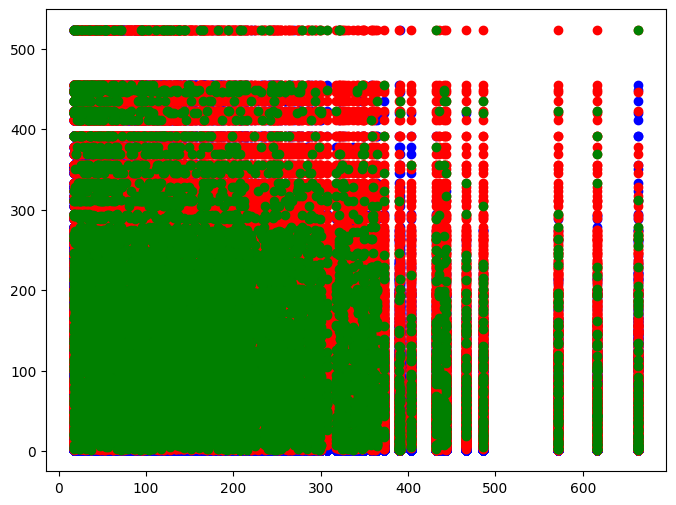

In [24]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot()



green = df[df["label"] == 1].copy().drop(columns=["original","label"])
blue = df[(df["label"] == 0) & (df["original"]==0)].copy().drop(columns=["original","label"])
red = df[(df["original"] == 1)].copy().drop(columns=["original","label"])

ax.scatter(x=blue["left_degree"],y= blue["right_degree"],c="blue")
ax.scatter(x=red["left_degree"],y= red["right_degree"],c="red")
ax.scatter(x=green["left_degree"],y= green["right_degree"],c="green")


# plt.scatter(df["kurt_base"].values,df["skew_base"].values)
plt.show()

In [27]:

verbose = False
df = df_base.copy().rename(columns={"kurt": "kurt_base", "skew": "skew_base"})
if df_inv is not None and not df_inv.empty:
    df_inv = df_inv.rename(columns={"kurt": "kurt_inv", "skew": "skew_inv"})
    df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]] = \
        df_inv[["rightNode", "leftNode", "kurt_inv", "skew_inv"]]
    df = df.merge(
        df_inv[["leftNode", "rightNode", "kurt_inv", "skew_inv"]],
        on=["leftNode", "rightNode"], how="left"
    )
else:
    df["kurt_inv"] = np.nan
    df["skew_inv"] = np.nan

df["lg_left_degree"]  = np.log1p(df["left_degree"].fillna(0).astype(float))
df["lg_right_degree"] = np.log1p(df["right_degree"].fillna(0).astype(float))

# --- labels ---
tmp  = df[["leftNode", "rightNode"]].copy()
excl = readFormatExcludedlinks(test_graph_path)[["leftNode", "rightNode"]].astype(str)
excl["_is_label"] = 1
tmp  = tmp.merge(excl, on=["leftNode", "rightNode"], how="left")

oe   = pd.read_csv(train_graph_path, header=None)\
            .rename(columns={0: "leftNode", 1: "rightNode"}).astype(str)
oe["_is_train"] = 1
tmp  = tmp.merge(oe, on=["leftNode", "rightNode"], how="left")

tmp["_is_label"] = tmp["_is_label"].fillna(0).astype(int)
tmp["_is_train"] = tmp["_is_train"].fillna(0).astype(int)

df["label"]    = tmp["_is_label"].values
df["original"] = (tmp["_is_train"] | tmp["_is_label"]).astype(int).values

# --- splits ---
idx_red   = df.index[df["original"] == 1].values
idx_blue  = df.index[(df["label"] == 0) & (df["original"] == 0)].values
idx_green = df.index[df["label"] == 1].values

train_blue_idx, holdout_blue_idx = train_test_split(
    idx_blue, test_size=holdout_blue_frac, random_state=random_state
)

test_idx     = np.concatenate([idx_green, holdout_blue_idx])
df_test_feac = df.loc[test_idx].reset_index(drop=True)

train_idx = np.concatenate([idx_red, train_blue_idx])

# --- experimentos ---
results["degrees_only"]    = train_eval_knn(["lg_left_degree", "lg_right_degree"],
                                                df, df_test_feac, train_idx)
results["moments_only"]    = train_eval_knn(["kurt_base", "skew_base"],
                                                df, df_test_feac, train_idx)
results["moments_only2"]    = train_eval_knn(["kurt_base", "skew_base","ext_moment"],
                                                df, df_test_feac, train_idx)

print(results)


{'aupr': 0.14245149388383402, 'auroc': 0.8709919427458084}
{'aupr': 0.41898682014763156, 'auroc': 0.9752300179796226}
{'aupr': 0.41608771713662945, 'auroc': 0.9750154419530894}
{'degrees_only': None, 'moments_only': None, 'moments_combined': {}, 'moments_inv': {}, 'moments_only2': None}


In [44]:
import seaborn as sns

green_idx = df[df["label"] == 1]
blue_idx = df[(df["label"] == 0) & (df["original"] == 0)]
red_idx = df[df["original"] == 1]

from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

feat_cols = ["kurt_base", "skew_base", "ext_moment"]  # suas 3 variáveis

# normalizar
scaler = StandardScaler()
X = scaler.fit_transform(df[feat_cols].fillna(0).values)
df["label"] = (df["label"] + df["original"])
y = df["label"].unique()

print(df)
# centroides por classe
classes   = np.unique(y)
centroids = np.array([X[y == c].mean(axis=0) for c in classes])
labels    = {0: "False edge", 1: "Real edge", 2: "Masked edge"}
colors    = {0: "blue",       1: "red",        2: "green"}

# distâncias entre centroides
dists = cdist(centroids, centroids)
print("\nDistâncias entre centroides (espaço normalizado):")
for i, ci in enumerate(classes):
    for j, cj in enumerate(classes):
        if j > i:
            print(f"  {labels[ci]} <-> {labels[cj]}: {dists[i,j]:.4f}")

# plot 3D
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")

for c in classes:
    mask = y == c
    ax.scatter(X[mask, 0], X[mask, 1], X[mask, 2],
               c=colors[c], label=labels[c], alpha=0.3, s=8)

# centroides maiores
for i, c in enumerate(classes):
    ax.scatter(*centroids[i], c=colors[c], s=120, marker="X", edgecolors="black", linewidths=0.8)

# linhas entre centroides com distância anotada
for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        xs = [centroids[i,0], centroids[j,0]]
        ys = [centroids[i,1], centroids[j,1]]
        zs = [centroids[i,2], centroids[j,2]]
        mid = [(a+b)/2 for a,b in zip(centroids[i], centroids[j])]
        ax.plot(xs, ys, zs, "k--", linewidth=0.8, alpha=0.5)
        ax.text(mid[0], mid[1], mid[2], f"{dists[i,j]:.2f}",
                fontsize=8, ha="center")

ax.set_xlabel(feat_cols[0])
ax.set_ylabel(feat_cols[1])
ax.set_zlabel(feat_cols[2])
ax.set_title("Separação dos clusters — espaço normalizado")
ax.legend()
plt.tight_layout()
plt.show() 


             file leftNode rightNode  kurt_base  skew_base  left_degree  \
0         1_1.csv        1       944   2.092057   1.752274          244   
1         1_1.csv        1       945   2.609903   2.552662          244   
2         1_1.csv        1       946  21.435866   4.830523          244   
3         1_1.csv        1       947   1.523006   1.844098          244   
4         1_1.csv        1       948  20.637275   5.154804          244   
...           ...      ...       ...        ...        ...          ...   
1575748  1_99.csv       99      2621   5.938333   1.117369          122   
1575749  1_99.csv       99      2622   5.938333   1.117369          122   
1575750  1_99.csv       99      2623   5.938333   1.117369          122   
1575751  1_99.csv       99      2624   0.293290   1.024299          122   
1575752  1_99.csv       99      2625   2.464472   1.485264          122   

         right_degree  ext_moment  kurt_inv  skew_inv  lg_left_degree  \
0                 411    0

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1575753 but size of corresponding boolean axis is 3